<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project-2/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Housing

## Problem Definition


The goal is to minimize the RMS percentage error ( root mean squared percentage error - RMSPE ) on the prediction of the house sales price using the Iowa Housing information.  This is a supervised regression problem using different housing features to determine the housing price.

## Data Collection/Sources


The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv .

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

### File path

In [ ]:
project2_path = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
training2_path = project2_path + 'Housing.Data.csv'
testing2_path = project2_path + 'Housing.Data.csv'


###IDA

In [ ]:
!curl -s -I {project2_path}

HTTP/1.1 200 OK
x-amz-id-2: RMHuyXvfdK88QCYCnkhRTffBwzy1KwDVfXf21xgGCpVrkoPWOjTwLUHJoNxWr3P7ipOii/PfTHoq1Zh7GgaEMIR7N2gjXY9P
x-amz-request-id: DFBXE1TVX2CDQ5JY
Date: Thu, 16 Apr 2026 21:46:08 GMT
Last-Modified: Fri, 06 Oct 2023 04:00:27 GMT
ETag: "76e84c9ee7f6fd4d51276697f81e76e1"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 880420
Server: AmazonS3



In [ ]:
training2_path

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csvHousing.Data.csv'

In [ ]:
my_url = project2_path
my_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

## Data Cleaning


In [ ]:
df = pd.read_csv(my_url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
df.shape

(2637, 81)

In [ ]:
df.describe(include = 'all').transpose().shape

(81, 11)

In [ ]:
df.describe(include = 'all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PID,2637.0,NaN,NaN,NaN,714130147.70383,188752674.750322,526301100.0,528477010.0,535453040.0,907187010.0,1007100110.0
MS SubClass,2637.0,NaN,NaN,NaN,57.349261,42.499091,20.0,20.0,50.0,70.0,190.0
MS Zoning,2637,7,RL,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2188.0,NaN,NaN,NaN,69.166819,23.356779,21.0,58.0,68.0,80.0,313.0
Lot Area,2637.0,NaN,NaN,NaN,10044.694729,6742.549521,1300.0,7436.0,9450.0,11526.0,164660.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2637.0,NaN,NaN,NaN,6.243838,2.722093,1.0,4.0,6.0,8.0,12.0
Yr Sold,2637.0,NaN,NaN,NaN,2007.795601,1.306403,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2637,10,WD,2286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2637,6,Normal,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [ ]:
df.isnull().sum()*100

,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,44900
Lot Area,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
df.dropna(axis = 'columns')#same as before because columns = 1

,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,14299,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2007,WD,Normal,115400
1,905101330,90,RL,10791,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,10,2006,WD,Normal,90000
2,903454090,50,RM,9000,Pave,Reg,Bnk,AllPub,Inside,Gtl,...,0,0,126,0,0,12,2007,WD,Normal,141000
3,533244030,60,FV,7379,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,254000
4,909252020,70,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,6240,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,10778,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,3782,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,10140,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2009,WD,Normal,165000


In [ ]:
df.isna().sum().sort_values(ascending=False)*100#number of rows with nulls

,0
Pool QC,262600
Misc Feature,254100
Alley,245700
Fence,210900
Mas Vnr Type,160700
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
#create a copy
df_backup = df.copy()
df_backup

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
#to restore df from the df_backup copy
df = df_backup.copy()
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
df_numerical = df.select_dtypes(include = ['int64', 'float64'])#choose only numerical columns
df_numerical.shape
df_numerical

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,905101070,20,62.0,14299,4,3,1964,1964,0.0,513.0,...,0,0,0,0,0,0,0,7,2007,115400
1,905101330,90,72.0,10791,4,5,1967,1967,0.0,0.0,...,0,0,0,0,0,0,500,10,2006,90000
2,903454090,50,50.0,9000,6,6,1937,1950,0.0,0.0,...,0,162,0,0,126,0,0,12,2007,141000
3,533244030,60,68.0,7379,8,5,2000,2000,0.0,484.0,...,280,184,0,0,0,0,0,4,2010,254000
4,909252020,70,60.0,7200,7,9,1936,2007,0.0,350.0,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,52.0,6240,6,6,1934,1950,0.0,0.0,...,112,0,0,0,0,0,400,9,2006,114500
2633,906201021,80,74.0,10778,7,6,1990,1991,0.0,460.0,...,114,36,0,0,0,0,0,7,2009,162000
2634,533253070,120,61.0,3782,8,5,1981,1981,0.0,960.0,...,133,78,0,0,0,0,0,9,2009,211500
2635,527376100,20,78.0,10140,6,5,1974,1974,174.0,0.0,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
# Drop all columns that contain at least one null value
df_clean = df_numerical.dropna(axis=1)

In [ ]:
#to double check there are no nulls anymore
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   PID              2637 non-null   int64
 1   MS SubClass      2637 non-null   int64
 2   Lot Area         2637 non-null   int64
 3   Overall Qual     2637 non-null   int64
 4   Overall Cond     2637 non-null   int64
 5   Year Built       2637 non-null   int64
 6   Year Remod/Add   2637 non-null   int64
 7   1st Flr SF       2637 non-null   int64
 8   2nd Flr SF       2637 non-null   int64
 9   Low Qual Fin SF  2637 non-null   int64
 10  Gr Liv Area      2637 non-null   int64
 11  Full Bath        2637 non-null   int64
 12  Half Bath        2637 non-null   int64
 13  Bedroom AbvGr    2637 non-null   int64
 14  Kitchen AbvGr    2637 non-null   int64
 15  TotRms AbvGrd    2637 non-null   int64
 16  Fireplaces       2637 non-null   int64
 17  Wood Deck SF     2637 non-null   int64
 18  Open Por

In [ ]:
df_clean = df_clean.drop('PID', axis=1)
df_clean

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   MS SubClass      2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   1st Flr SF       2637 non-null   int64
 7   2nd Flr SF       2637 non-null   int64
 8   Low Qual Fin SF  2637 non-null   int64
 9   Gr Liv Area      2637 non-null   int64
 10  Full Bath        2637 non-null   int64
 11  Half Bath        2637 non-null   int64
 12  Bedroom AbvGr    2637 non-null   int64
 13  Kitchen AbvGr    2637 non-null   int64
 14  TotRms AbvGrd    2637 non-null   int64
 15  Fireplaces       2637 non-null   int64
 16  Wood Deck SF     2637 non-null   int64
 17  Open Porch SF    2637 non-null   int64
 18  Enclosed

In [ ]:
#gives me more idea of what I am dealing with. to be sure there is no more unique columns
df_clean.nunique()

,0
MS SubClass,16
Lot Area,1799
Overall Qual,10
Overall Cond,9
Year Built,118
Year Remod/Add,61
1st Flr SF,1022
2nd Flr SF,589
Low Qual Fin SF,31
Gr Liv Area,1216


## EDA

### Filter Methods
With filter methods, we will calculate a statistical metric for each column. Based on that metric, it will be decided whether that feature will be kept or removed from our predictive model. *Note*: the choice of statistical metric depends on the data type of the feature.

In [ ]:
# Sort correlations w/ price
df_clean.corr()['SalePrice'].abs().sort_values(ascending = False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932
TotRms AbvGrd,0.493853
Fireplaces,0.468886
Wood Deck SF,0.322060


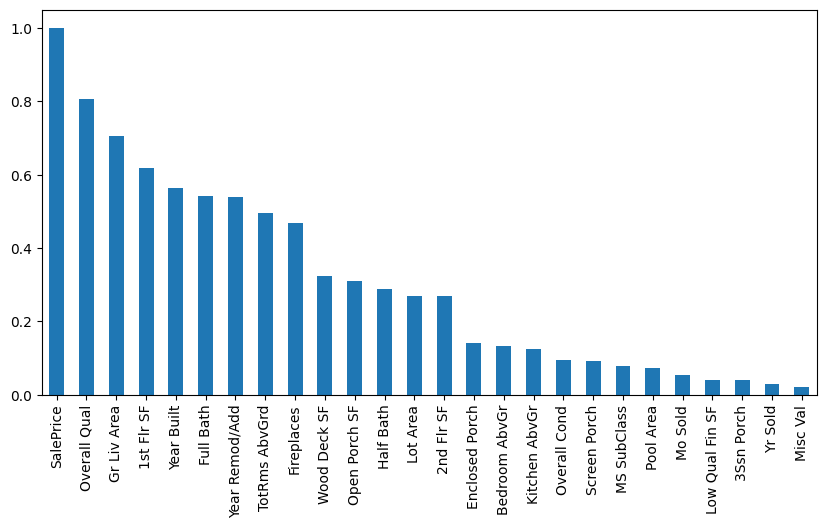

In [ ]:
# Plot result
df_clean.corr()['SalePrice'].abs().sort_values(ascending = False).plot(kind = 'bar', figsize = (10,5))
plt.savefig('corr1.png')

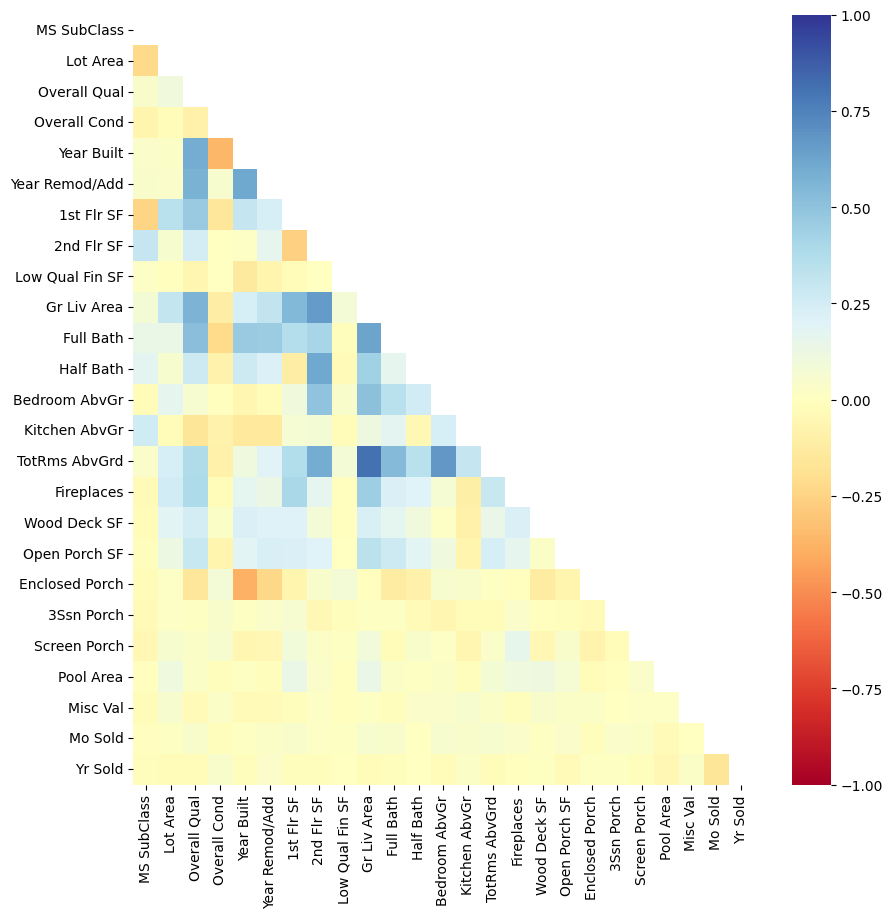

In [ ]:
corr = df_clean.drop(columns=['SalePrice']).corr()
ones = np.ones_like(
    corr,
    dtype=bool,
)
mask = np.tril(ones, k=-1)
lower_triangle_corr = corr.where(mask)

plt.figure(figsize=(10,10))
sns.heatmap(lower_triangle_corr, cmap='RdYlBu',annot = False, vmin = -1, vmax = 1)
plt.savefig('masked.png')

In [ ]:
lt_df = (
  lower_triangle_corr
  .unstack()
  .to_frame()
  .rename( columns={0:"A"} )
  .query( "A > 0.70")
  .sort_values( by = "A", ascending=False )
  .reset_index()
)
lt_df

,level_0,level_1,A
0,Gr Liv Area,TotRms AbvGrd,0.807065


In [ ]:
df_clean.columns

Index(['MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'],
      dtype='object')

In [ ]:
df_clean.drop(columns=['TotRms AbvGrd']).columns.sort_values().to_list()

['1st Flr SF',
 '2nd Flr SF',
 '3Ssn Porch',
 'Bedroom AbvGr',
 'Enclosed Porch',
 'Fireplaces',
 'Full Bath',
 'Gr Liv Area',
 'Half Bath',
 'Kitchen AbvGr',
 'Lot Area',
 'Low Qual Fin SF',
 'MS SubClass',
 'Misc Val',
 'Mo Sold',
 'Open Porch SF',
 'Overall Cond',
 'Overall Qual',
 'Pool Area',
 'SalePrice',
 'Screen Porch',
 'Wood Deck SF',
 'Year Built',
 'Year Remod/Add',
 'Yr Sold']

In [ ]:
df_clean.drop(columns=['TotRms AbvGrd'], inplace= True)
df_clean

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


## Processing

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# split into Target and Features
X = df_clean.drop('SalePrice', axis = 1)
y = df_clean['SalePrice']

In [ ]:
#calculating the %
def calculate_rmspe(y_true, y_pred):
    """
    Calculate the Root Mean Squared Percentage Error.
    """
    # Convert inputs to numpy arrays for vectorization
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Calculate percentage error (actual - predicted) / actual
    # We square the results, take the mean, and then the square root
    rmspe = np.sqrt(np.mean(np.square((y_true - y_pred) / y_true))) * 100

    return rmspe



In [ ]:
# Perform CV
n = 500
results = np.zeros(n)
for idx in range(n):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  results[idx] = calculate_rmspe(y_test, y_pred)
print(f"CV RMSPE: {results.mean().round(2)}%")
print(f"Number of Predictors: {len(X.columns)}")


# Example usage with your model results:
# rmspe_score =
# print(f"RMSPE: {rmspe_score:.2f}%")



CV RMSPE: 20.29%
Number of Predictors: 24


## Regularization

### Using Lasso, determine the best alpha

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
df_clean

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
#to create a copy of my new dataframe
df_clean_bak = df_clean.copy()
df_clean_bak.shape


(2637, 25)

In [ ]:
# to be sure I can restore
df_clean = df_clean_bak.copy()
df_clean

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
# %%capture --no-stdout
X_lasso = df_clean.drop('SalePrice', axis = 1)
y_lasso = df_clean['SalePrice']

# Specify values of alpha we want to try
alph = [1, 2, 3, 4, 5, 6, 10, 20, 40, 50, 75, 100, 200, 300, ]
alph = [75, 100, 200, 300, ]
alph = [20, 40, 50, 75, 100, 200, 300, 350, 400, 450, 500]

# Create empty list to hold results
results_alpha = []

for i in alph:
  # Calculate CV RMSE
  n = 200
  results = np.zeros(n)

  for idx in range(n):
    # Create the model
    my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=10_000); # Looping through alpha

    # Train, test split
    X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

    # Standard scale only training features
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)

    # Scale testing features
    X_test = scaler.transform(X_test)

    # Fit regression
    my_fit_lasso.fit(X_train, y_train)

    # Predict
    y_pred = my_fit_lasso.predict(X_test)

    # Calculate and record performance metric
    results[idx] = np.sqrt(mean_squared_error(y_test,y_pred))

  results_alpha.append(results.mean())#append individual alpha to a list

results_df = pd.DataFrame({'Alpha': alph, 'RMSE': results_alpha})#take list of alphas and list of means and convert in a df.


In [ ]:
results_df.sort_values( by = 'RMSE' )#got to see what is the smallest rmse

,Alpha,RMSE
7,350,33777.219599
9,450,33914.619841
6,300,33960.392634
3,75,34035.237893
5,200,34078.730936
4,100,34135.337748
8,400,34185.058757
10,500,34200.562515
0,20,34376.228679
2,50,34490.996020


In [ ]:
alpha = results_df.sort_values( by = 'RMSE' )["Alpha"].iloc[0]
alpha

np.int64(350)

In [ ]:
# %%capture --no-stdout
# Perform CV
n = 500
results = np.zeros(n)

for idx in range(n):
  # Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.25)

  # Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  # Scale testing features
  X_test = scaler.transform(X_test)

  # Create the model
  model = Lasso(alpha = alpha, tol = .01, max_iter=10000)

  # Fit regression
  model.fit(X_train, y_train)

  # Predict
  y_pred = model.predict(X_test)

  # Calculate and record performance metric
  results[idx] = np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))

print(f"CV RMSPE: {results.mean():.2%}")
print(f"Number of Predictors: {sum(model.coef_ >0)}")

CV RMSPE: 20.37%
Number of Predictors: 15


In [ ]:
X_lasso.shape

(2637, 24)

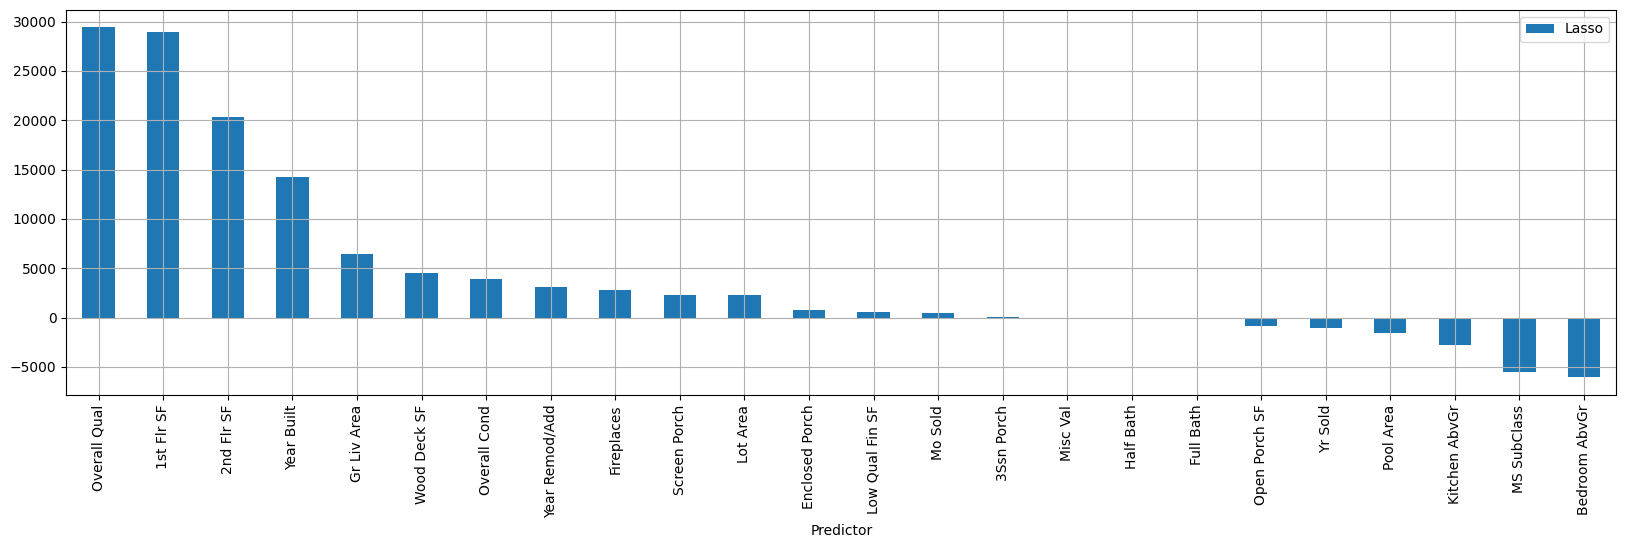

In [ ]:
# Plot model coefficients
model_results = pd.DataFrame()
model_results['Predictor'] = X_lasso.columns
model_results['Lasso'] = model.coef_
model_results.sort_values( by = ["Lasso"], ascending = False ).plot(
    x = 'Predictor',
    kind = 'bar',
    figsize = (20,5)
    )
plt.grid()
plt.savefig('betas_lasso.png')

In [ ]:
model_results.sort_values(by=['Lasso'])

,Predictor,Lasso
12,Bedroom AbvGr,-6067.981211
0,MS SubClass,-5525.713639
13,Kitchen AbvGr,-2752.412208
20,Pool Area,-1564.962772
23,Yr Sold,-1017.318766
16,Open Porch SF,-826.362203
10,Full Bath,-19.832566
11,Half Bath,0.000000
21,Misc Val,-0.000000
18,3Ssn Porch,86.994288


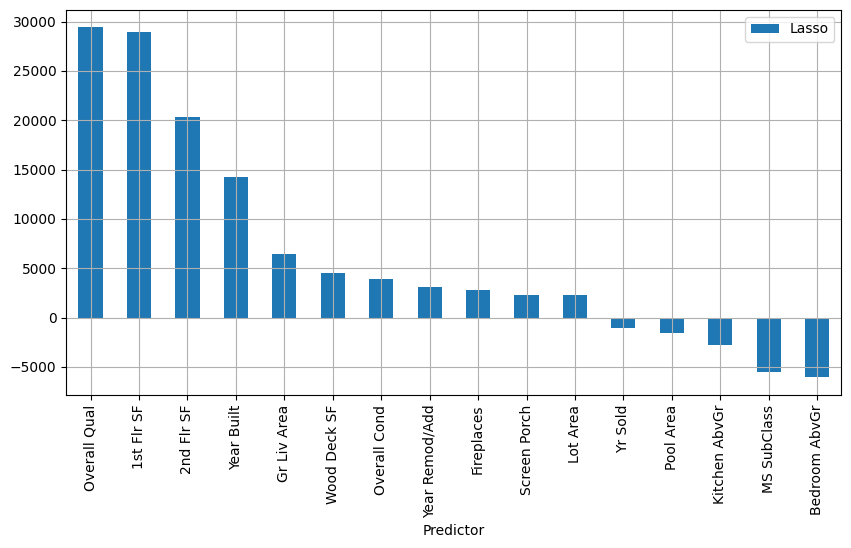

In [ ]:
# Plot parameters with coefficients greater than 0
greater_1000= model_results[(model_results['Lasso'] > 1000 ) | (model_results['Lasso'] < -1000)]
greater_1000.sort_values( by = ["Lasso"], ascending = False ).plot(x = 'Predictor', kind = 'bar', figsize = (10,5))
plt.grid()

## Residual Analysis

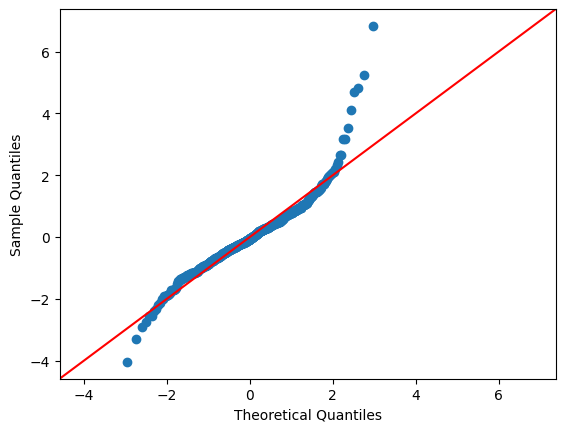

In [ ]:
# # QQ Plot - Residuals are normally distributed

res = y_test - y_pred
sm.qqplot(res, fit=True, line="45")
plt.savefig('residual.png')

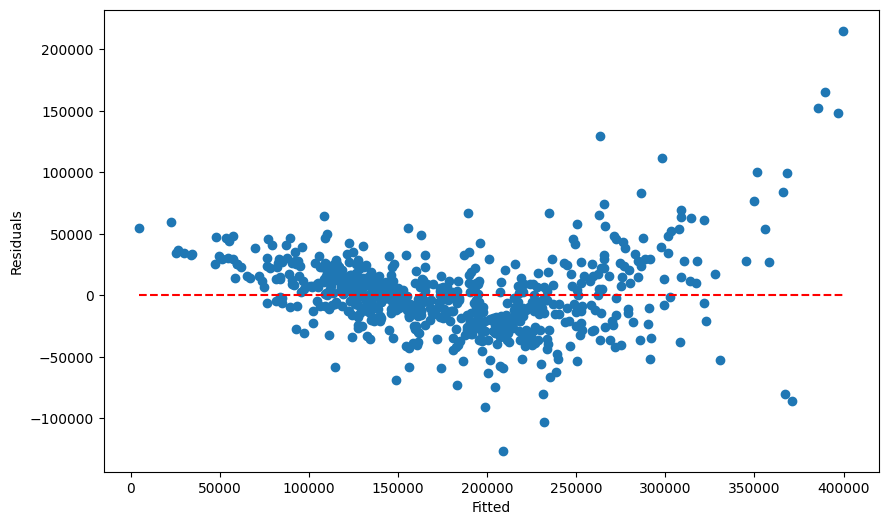

In [ ]:
# # Residuals vs Fitted (Predicted) Values - Constant variance
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed')
plt.savefig('resvsfitted')

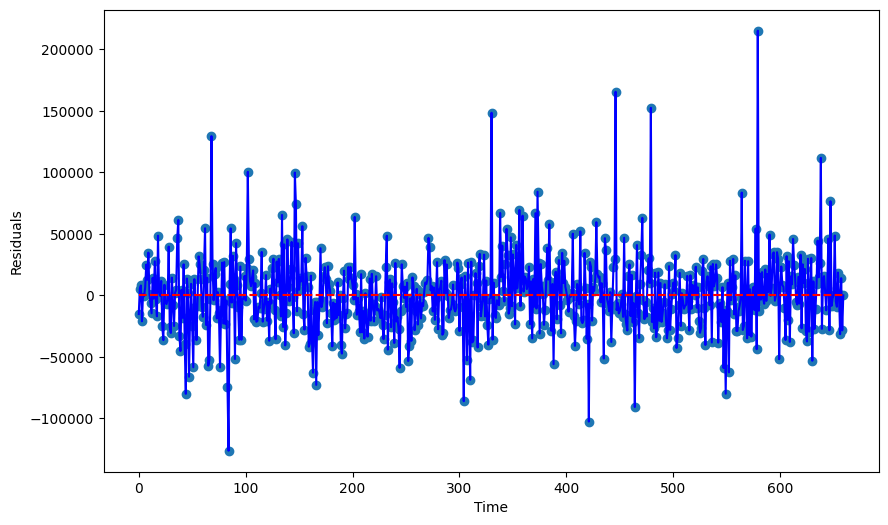

In [ ]:
# # Residuals vs Time - indepedence
plt.figure(figsize = (10,6))
plt.scatter(range(len(res)), res)
plt.plot(range(len(res)), res, 'b')
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.hlines(0, min(range(len(res))), max(range(len(res))), colors = 'red', linestyles = 'dashed')
plt.savefig('resvstime')

## Data Visualization/Communication of Results


### Conclusion


Used 2 very different approaches to analyze the Iowa Housing data: manual and quantitative selection of features.
The RMSPE range obtained was between 19% and 33% depending on the approach
The minimum number of features used was obtained when the manual approach was used = 1.  The quantitative approach led to a minimum of 14 variables being used.
### Limitations:
Some features were inter-dependent
Data was cleaned of nulls, but some noise remained
Residual distribution was not normal
### Future plans:
Remove features identified by the Lasso model and reanalyze the data
Use other models as we learn more tools